# -- Customer Intelligence System using (Classification, Ensemble Learning & Clustering)

##  Assignment Description

Developed an end-to-end **Customer Intelligence System** to analyze and segment countries based on socio-economic and development indicators. The project integrates **Clustering**, **Classification**, and **Ensemble Learning** techniques to uncover hidden patterns, generate meaningful segments, and build predictive models for country categorization.

###  Key Highlights

- Performed **data preprocessing, feature engineering, and exploratory data analysis (EDA)** on socio-economic data.
- Applied **K-Means** and **DBSCAN** clustering algorithms to identify distinct country segments and detect outliers.
- Built predictive classification models using **Random Forest** and **XGBoost**.
- Leveraged **Ensemble Learning** techniques to improve model accuracy, robustness, and generalization.
- Evaluated model performance using industry-standard metrics and comparative analysis.
- Generated actionable insights to support data-driven decision-making and development assessment.

###  Technologies Used

**Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, XGBoost, K-Means, DBSCAN, Random Forest**

# 1. Import Libraries

In this step, we import all necessary Python libraries for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine Learning (scikit-learn, XGBoost)

These libraries form the backbone of our Customer Intelligence System.

In [212]:
# ============================================================
# 1.0 IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    davies_bouldin_score
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

from xgboost import XGBClassifier

print("Libraries Imported Successfully ✓")

Libraries Imported Successfully ✓


# 2. Dataset Loading

We load the Country dataset containing socio-economic indicators such as:
- GDP per capita (gdpp)
- Income
- Child mortality
- Health and education indicators

This dataset will be used for clustering and classification tasks.

In [215]:
# ============================================================
# 2.0 LOAD DATASET
# ============================================================

df = pd.read_csv(
    "Country-data.csv"
)

print(
    "Dataset Loaded Successfully ✓"
)

print(
    "\nDataset Shape :",
    df.shape
)

df.head()

Dataset Loaded Successfully ✓

Dataset Shape : (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Data Understanding
We explore:
- Shape of dataset
- Column types
- Missing values
- Basic structure

This helps in understanding data quality before modeling.

In [218]:
# ============================================================
# 3.0 DATA UNDERSTANDING
# ============================================================

print(
    "Rows    :",
    df.shape[0]
)

print(
    "Columns :",
    df.shape[1]
)

print("\nColumn Names :")

print(
    df.columns.tolist()
)

print("\nDataset Information")

df.info()

Rows    : 167
Columns : 10

Column Names :
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [220]:
# ============================================================
# 2.0 LOAD DATASET
# ============================================================

df = pd.read_csv("Country-data.csv")

print("Dataset Loaded Successfully ✓")

print("Data Dimensions:", df.shape)

print("\nMissing values in columns:")

print(df.isnull().sum())

df.head()


Dataset Loaded Successfully ✓
Data Dimensions: (167, 10)

Missing values in columns:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# 4. Descriptive Statistics

We analyze statistical summaries:
- Mean
- Standard deviation
- Minimum and maximum values

This helps us understand data distribution and variability.

In [223]:
# ============================================================
# 4.0 DESCRIPTIVE STATISTICS
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 5. Data Quality Check
We check:
- Missing values
- Duplicate records

Ensures dataset reliability for modeling.

In [226]:
# ============================================================
# 5.0 MISSING VALUES
# ============================================================

missing = df.isnull().sum()

print(missing)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 6. Exploratory Data Analysis (EDA)

We analyze distributions of:
- Income
- GDP per capita
- Child mortality

This helps identify skewness and patterns in data.

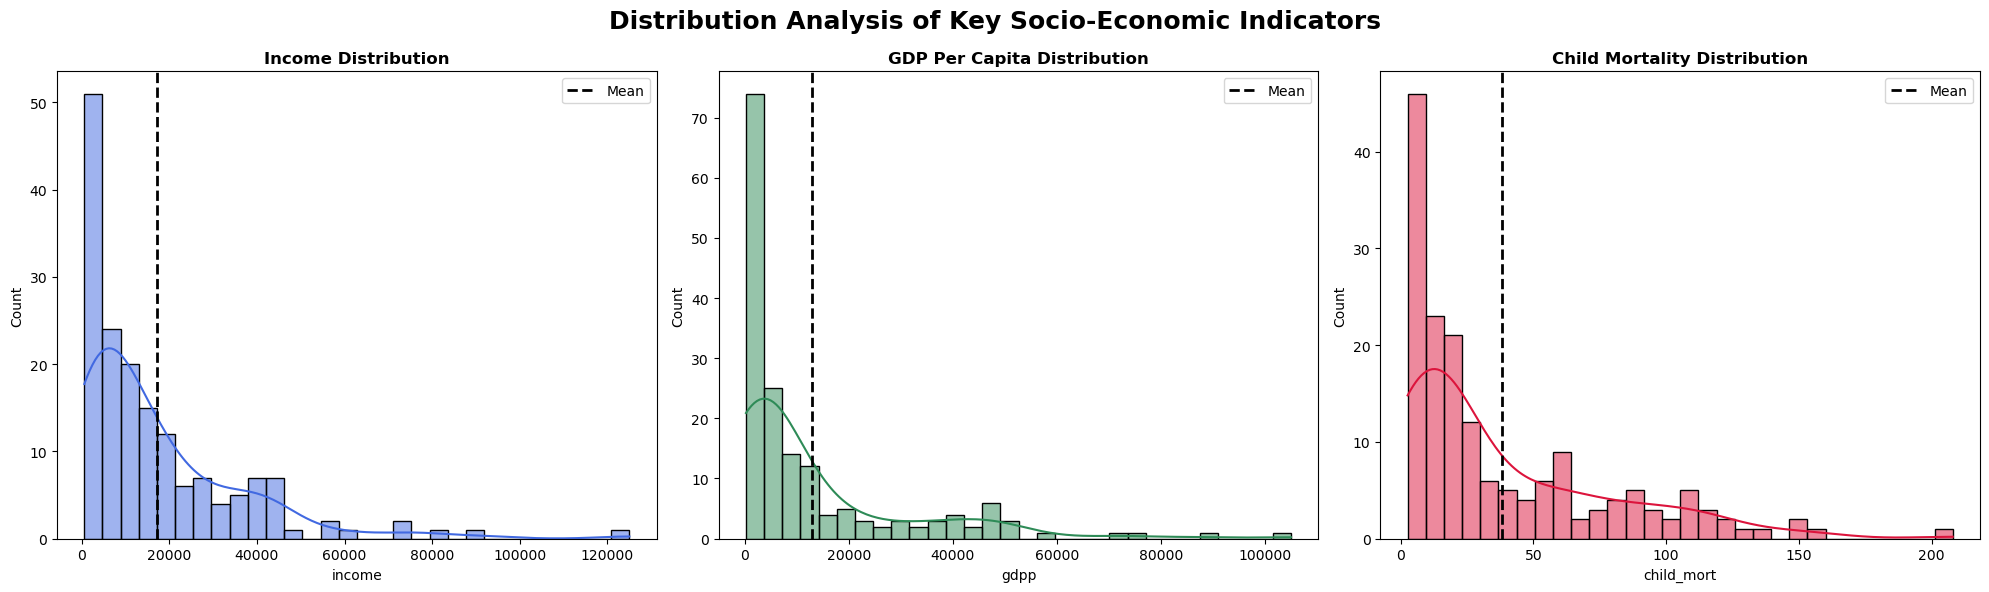

In [229]:
# ============================================================
# 6.0 DISTRIBUTION ANALYSIS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20,6)
)

features = [
    'income',
    'gdpp',
    'child_mort'
]

titles = [
    'Income Distribution',
    'GDP Per Capita Distribution',
    'Child Mortality Distribution'
]

colors = [
    'royalblue',
    'seagreen',
    'crimson'
]

for ax, feature, title, color in zip(
    axes,
    features,
    titles,
    colors
):

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True,
        color=color,
        ax=ax
    )

    ax.axvline(
        df[feature].mean(),
        color='black',
        linestyle='--',
        linewidth=2,
        label='Mean'
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold'
    )

    ax.legend()

fig.suptitle(
    "Distribution Analysis of Key Socio-Economic Indicators",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

## 7. Correlation Analysis

We study relationships between features.

Key Insight:
- GDP per capita is strongly related to income and life expectancy
- Child mortality is negatively correlated with development indicators

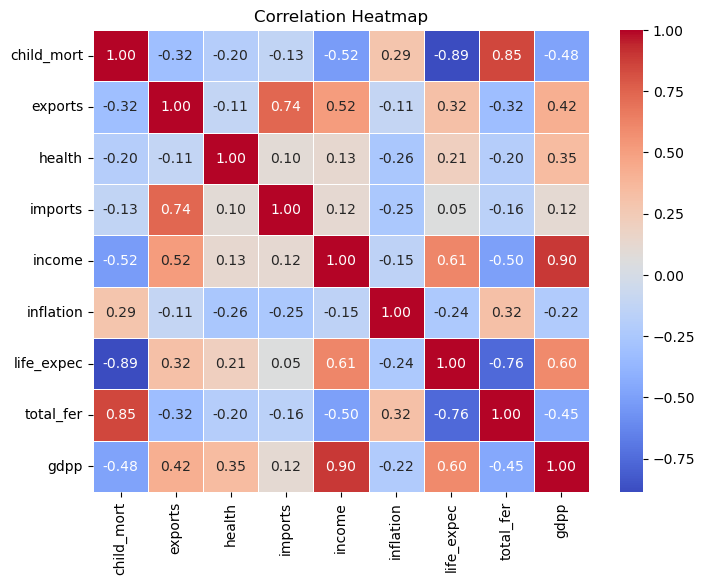

In [231]:
# ============================================================
# 7.0 CORRELATION ANALYSIS
# ============================================================


plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 8. Feature Engineering

We convert percentage-based features into actual values:
- exports
- imports
- health spending

This improves model accuracy and interpretability.

In [235]:
# ============================================================
# 8.0 FEATURE ENGINEERING
# ============================================================

df_clean = df.copy()

df_clean['exports'] = (
    df['exports'] *
    df['gdpp']
) / 100

df_clean['health'] = (
    df['health'] *
    df['gdpp']
) / 100

df_clean['imports'] = (
    df['imports'] *
    df['gdpp']
) / 100

print(
    "Feature Engineering Completed ✓"
)

df_clean.head()

Feature Engineering Completed ✓


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


# 9. Feature Scaling

We apply StandardScaler to normalize all features.

Why scaling is important:
- Ensures all variables contribute equally
- Essential for clustering algorithms like K-Means and DBSCAN

In [238]:
# ============================================================
# 9.0 FEATURE SCALING
# ============================================================

X_raw = df_clean.drop(
    'country',
    axis=1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_raw
)

print("Feature Scaling Completed ✓")

Feature Scaling Completed ✓


# 10. Optimal Cluster Selection

We determine the optimal number of clusters using:
- Elbow Method (WCSS)
- Silhouette Score

This helps us choose the best K for K-Means clustering.

In [241]:
# ============================================================
# 10.0 OPTIMAL CLUSTER SELECTION
# ============================================================

wcss = []
silhouette_scores = []

k_values = range(2,8)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    wcss.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

# 10.1 Elbow + Silhouette Analysis

We evaluate clustering performance using:
- Within Cluster Sum of Squares (WCSS)
- Silhouette Score

This helps validate the best cluster count.

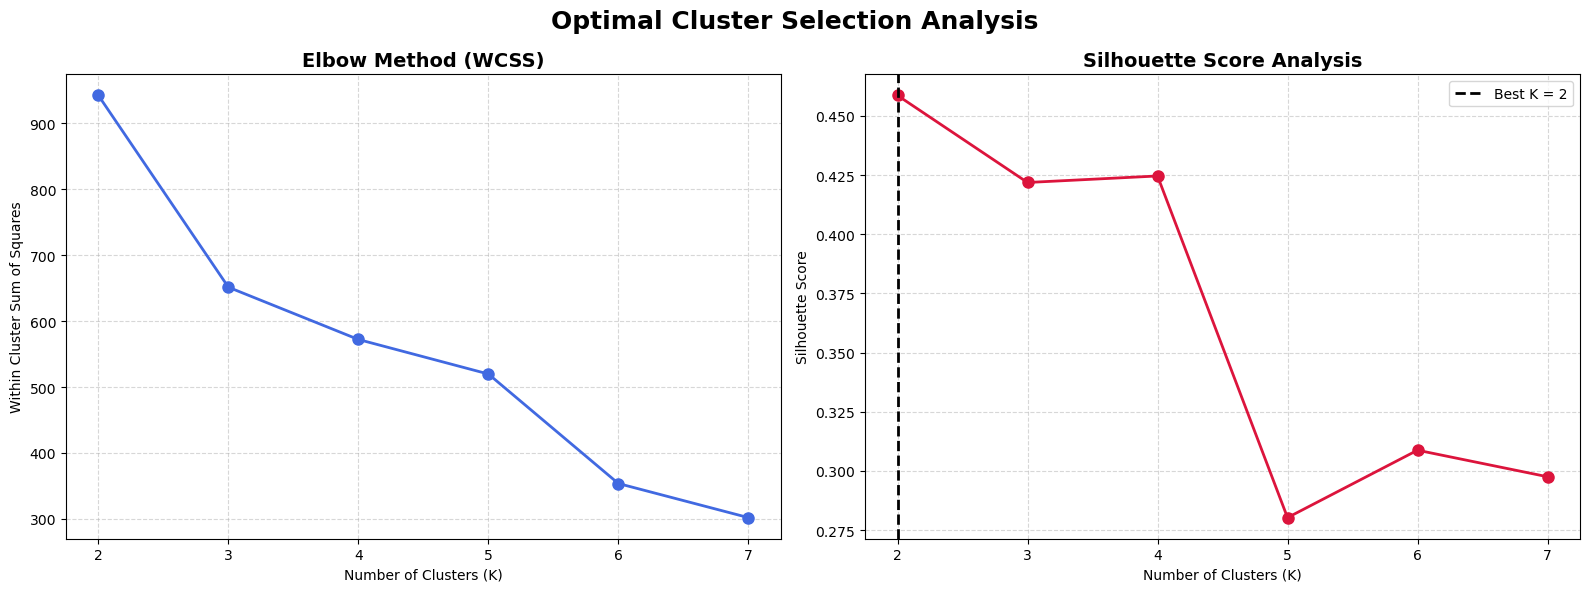

Optimal Number of Clusters (K) : 2
Best Silhouette Score : 0.4586


In [244]:
# ============================================================
# 10.1 ELBOW + SILHOUETTE ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].plot(
    k_values,
    wcss,
    marker='o',
    linewidth=2,
    markersize=8,
    color='royalblue'
)

axes[0].set_title(
    "Elbow Method (WCSS)",
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Within Cluster Sum of Squares")

axes[0].grid(
    linestyle='--',
    alpha=0.5
)

best_k = k_values[
    np.argmax(silhouette_scores)
]

best_score = max(
    silhouette_scores
)

axes[1].plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2,
    markersize=8,
    color='crimson'
)

axes[1].axvline(
    best_k,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Best K = {best_k}'
)

axes[1].set_title(
    "Silhouette Score Analysis",
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

axes[1].legend()

axes[1].grid(
    linestyle='--',
    alpha=0.5
)

fig.suptitle(
    "Optimal Cluster Selection Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

print("="*60)

print(
    f"Optimal Number of Clusters (K) : {best_k}"
)

print(
    f"Best Silhouette Score : {best_score:.4f}"
)

print("="*60)

# Hierarchical Clustering (Dendrogram)

## Objective
To visualize the hierarchical structure of data points and understand how clusters are formed step-by-step.

## What it shows:
- Relationship between data points
- Distance at which clusters merge
- Natural grouping structure in data

## Interpretation:
- Lower merges → similar data points
- Higher merges → dissimilar clusters
- Helps decide optimal number of clusters

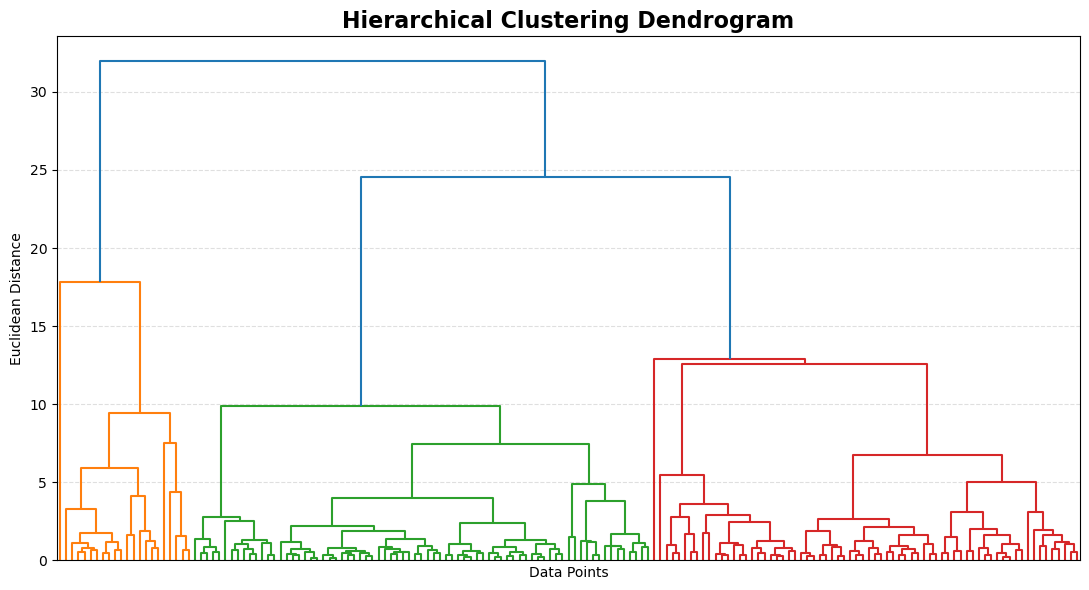

In [247]:
# ============================================================
# 10.1.1  Hierarchical Clustering (Dendrogram)
# ============================================================
from scipy.cluster.hierarchy import linkage, dendrogram

plt.figure(figsize=(11,6))

linkage_matrix = linkage(X_scaled, method='ward')

dendrogram(linkage_matrix, no_labels=True, color_threshold=None)

plt.title("Hierarchical Clustering Dendrogram", fontsize=16, fontweight='bold')
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 10.2 K-Means Clustering

We apply K-Means algorithm to segment countries into clusters based on socio-economic similarity.

In [250]:
# ============================================================
# 10.2 K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

df['Cluster'] = kmeans_labels

print("K-Means Completed ✓")

K-Means Completed ✓


# 11. Cluster Evaluation Metrics

We evaluate clustering performance using:
- Silhouette Score
- Davies-Bouldin Score

These metrics help measure cluster quality and separation.

In [253]:
# ============================================================
# 11.0 CLUSTER QUALITY METRICS
# ============================================================

from sklearn.metrics import davies_bouldin_score

print(
    "Silhouette Score :",
    round(
        silhouette_score(
            X_scaled,
            kmeans_labels
        ),
        4
    )
)

print(
    "Davies Bouldin Score :",
    round(
        davies_bouldin_score(
            X_scaled,
            kmeans_labels
        ),
        4
    )
)

Silhouette Score : 0.4219
Davies Bouldin Score : 0.8566


# 12. DBSCAN Clustering

We apply DBSCAN clustering to detect:
- Density-based clusters
- Outliers (noise points)

This complements K-Means clustering.

In [256]:
# ============================================================
# 12.0 DBSCAN CLUSTERING
# ============================================================

dbscan = DBSCAN(
    eps=1.5,
    min_samples=3
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(
    X_scaled
)

print("DBSCAN Completed ✓")

DBSCAN Completed ✓


# 13. Cluster Analysis

We analyze each cluster by calculating mean values of features.

This helps interpret:
- Underdeveloped countries
- Developing countries
- Developed countries

In [259]:
# ============================================================
# 13.0 CLUSTER ANALYSIS
# ============================================================

cluster_summary = (

    df.groupby(
        'Cluster'
    )

    .mean(
        numeric_only=True
    )

)

display(cluster_summary)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,91.610417,29.571042,6.433542,43.133333,3897.354167,11.911146,59.239583,4.992083,1909.208333,-0.083333
1,5.046429,60.789286,8.934643,51.857143,50178.571429,3.014679,80.514286,1.760714,48114.285714,-0.142857
2,20.357143,41.139440,6.365275,47.343581,13968.021978,7.070549,73.460440,2.235055,7979.912088,-0.021978


# 13. Cluster Visualization

We visualize clusters using:
- Income
- GDP per capita

This helps clearly separate different country segments.

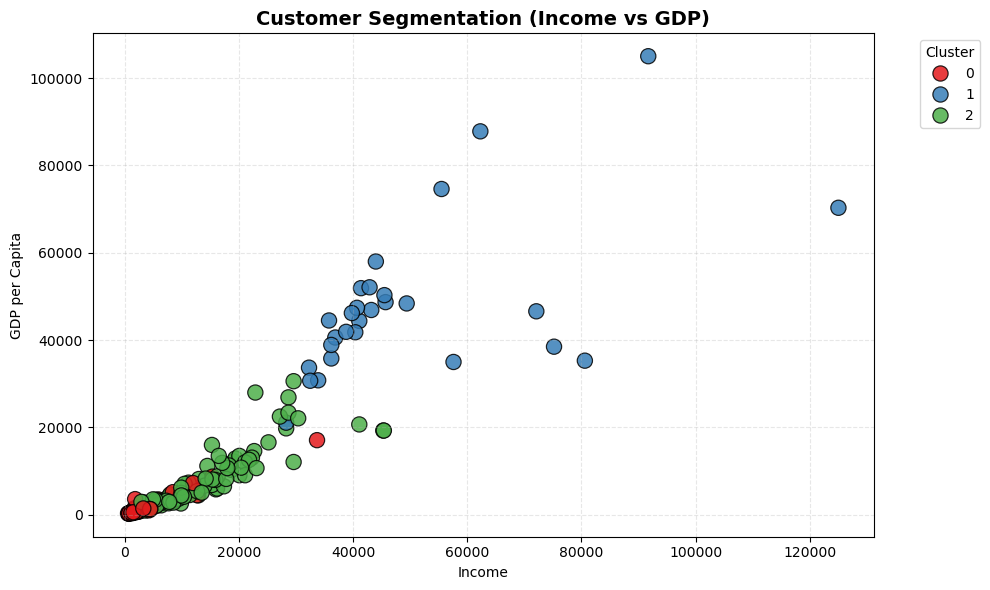

In [262]:
# ============================================================
# 13.0 Cluster Visualization
# ============================================================
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,x='income',y='gdpp',hue='Cluster',
                palette='Set1',s=120,edgecolor='black',alpha=0.85)

plt.title("Customer Segmentation (Income vs GDP)",fontsize=14,fontweight='bold')
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.grid(alpha=0.3,linestyle='--')

plt.legend(title="Cluster",bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

# 14. Segment Creation

We map clusters into meaningful business segments:
- Underdeveloped Countries
- Developing Countries
- Developed Countries

This makes results interpretable for real-world use.

In [265]:
# ============================================================
# 14.0 SEGMENT CREATION
# ============================================================

gdpp_ranks = (

    df.groupby(
        'Cluster'
    )['gdpp']

    .mean()

    .sort_values()

)

mapping = {

    gdpp_ranks.index[0]:0,
    gdpp_ranks.index[1]:1,
    gdpp_ranks.index[2]:2

}

df['Segment'] = df['Cluster'].map(
    mapping
)

print("Segment Created ✓")

Segment Created ✓


# 15. Train-Test Split

We split the dataset into training and testing sets:
- Training set: 80%
- Testing set: 20%

This ensures unbiased model evaluation.

In [268]:
# ============================================================
# 15.0 TRAIN TEST SPLIT
# ============================================================

X = df_clean.drop(
    'country',
    axis=1
)

y = df['Segment']

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Train Test Split Completed ✓")

Train Test Split Completed ✓


# 16. Random Forest Classifier

We train a Random Forest model to classify country segments based on socio-economic indicators.

In [271]:
# ============================================================
# 16.0 RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy :",
    round(rf_acc,4)
)

Random Forest Accuracy : 0.9706


# 17. XGBoost Classifier

We apply XGBoost, a powerful gradient boosting algorithm, for improved classification performance.

In [274]:
# ============================================================
# 17.0 XGBOOST
# ============================================================

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy :",
    round(xgb_acc,4)
)

XGBoost Accuracy : 0.9706


# 18. Model Comparison

We compare:
- Random Forest
- XGBoost

Based on accuracy scores to select the best model.

In [277]:
# ============================================================
# 18.0 MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    'Model':[
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[
        rf_acc,
        xgb_acc
    ]

})

display(comparison)

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


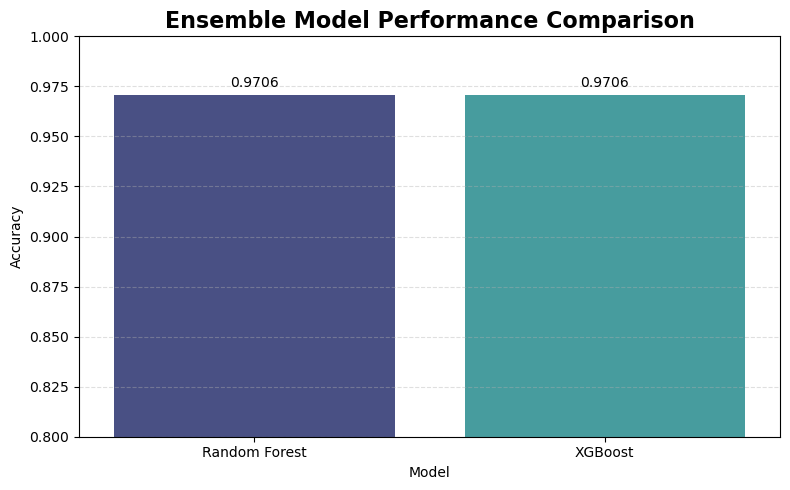

In [279]:
# ============================================================
# 18.1 CLASSIFIER PERFORMANCE COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy',
    palette='mako'
)

for c in ax.containers:
    ax.bar_label(c, fmt='%.4f', padding=4)

plt.title("Ensemble Model Performance Comparison",
          fontsize=16, fontweight='bold')

plt.ylim(0.80, 1.0)
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 18. Best Model Selection

We select the best performing model based on accuracy.

In [282]:
# ============================================================
# 18.2 BEST MODEL
# ============================================================

best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

display(best_model)

Model       Random Forest
Accuracy         0.970588
Name: 0, dtype: object

In [284]:
# ============================================================
# 18.2 BEST MODEL PREDICTIONS
# ============================================================

if rf_acc >= xgb_acc:

    best_pred = rf_pred

    model_name = "Random Forest"

    best_model_obj = rf

else:

    best_pred = xgb_pred

    model_name = "XGBoost"

    best_model_obj = xgb

print(
    f"Best Model : {model_name}"
)

Best Model : Random Forest


# 18. Confusion Matrix Analysis

We evaluate model performance using a confusion matrix to understand classification errors.

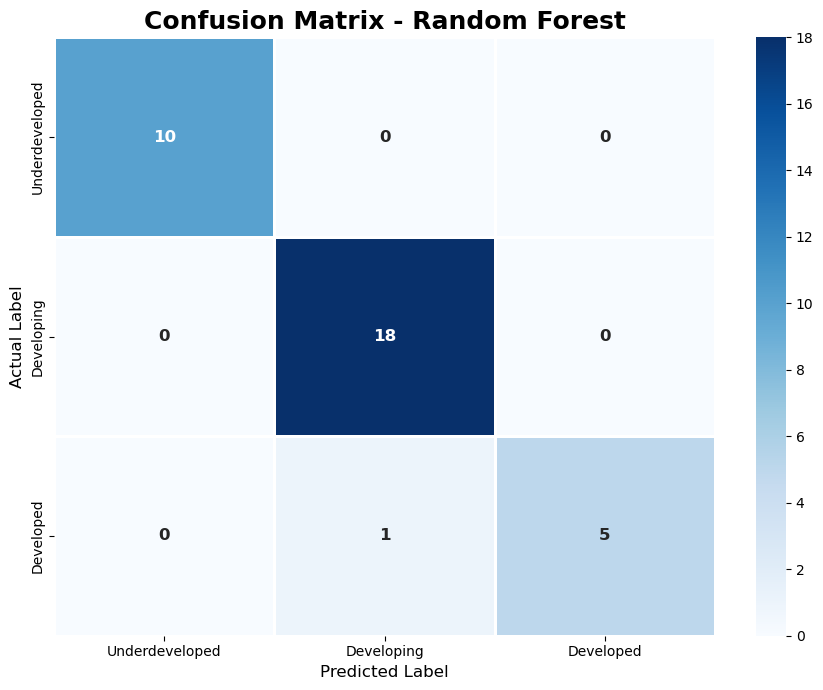

In [287]:
# ============================================================
# 18.3 CONFUSION MATRIX ANALYSIS
# ============================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

class_names = [

    "Underdeveloped",

    "Developing",

    "Developed"

]

plt.figure(
    figsize=(9,7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='white',
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={
        'fontsize':12,
        'fontweight':'bold'
    }
)

plt.title(
    f"Confusion Matrix - {model_name}",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "Actual Label",
    fontsize=12
)

plt.tight_layout()

plt.show()

# 19. Classification Report

We evaluate:
- Precision
- Recall
- F1-score

This gives a complete performance summary.

In [290]:
# ============================================================
# 19.0 CLASSIFICATION REPORT
# ============================================================

print(

    classification_report(
        y_test,
        best_pred
    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.95      1.00      0.97        18
           2       1.00      0.83      0.91         6

    accuracy                           0.97        34
   macro avg       0.98      0.94      0.96        34
weighted avg       0.97      0.97      0.97        34



# 20. Feature Importance

We identify important features influencing classification:
- GDP per capita
- Income
- Child mortality

These are key drivers of development.

In [293]:
# ============================================================
# 20.0 FEATURE IMPORTANCE
# ============================================================

if model_name == "Random Forest":

    importance = pd.DataFrame({

        'Feature':X.columns,

        'Importance':rf.feature_importances_

    })

    importance = importance.sort_values(
        by='Importance',
        ascending=False
    )

    display(importance)

,Feature,Importance
0,child_mort,0.197921
8,gdpp,0.178078
6,life_expec,0.170098
7,total_fer,0.148743
4,income,0.124343
1,exports,0.071966
2,health,0.053380
3,imports,0.043070
5,inflation,0.012400


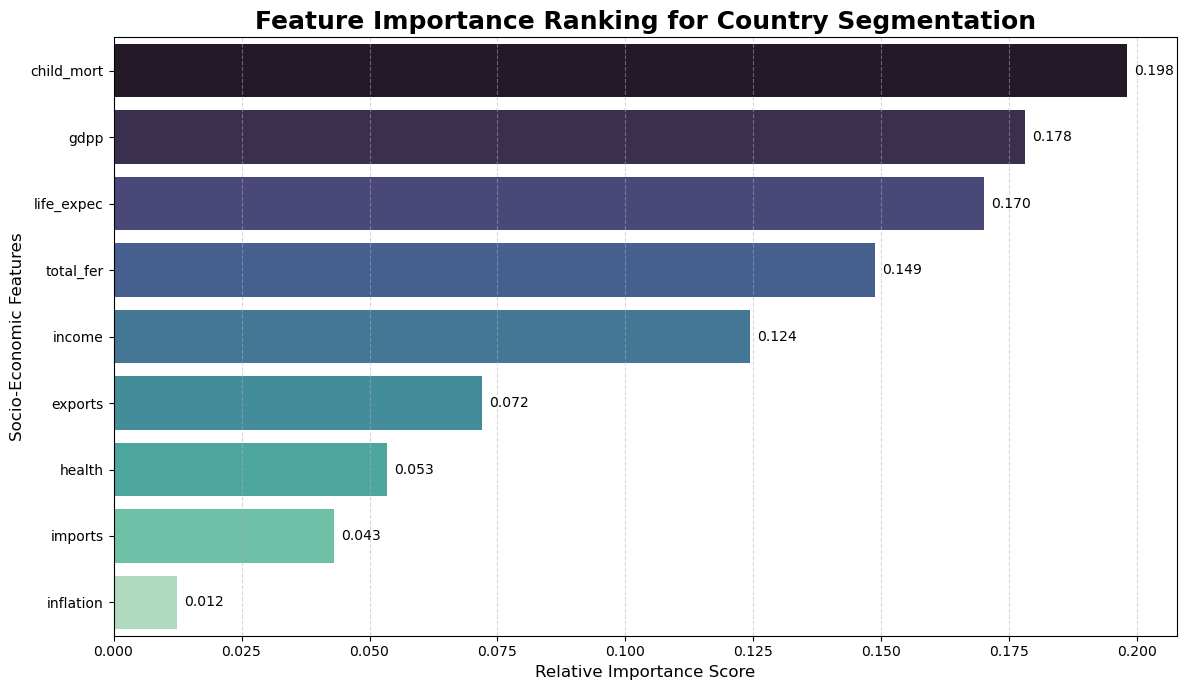

In [295]:
# ============================================================
# 20.1 FEATURE IMPORTANCE ANALYSIS
# ============================================================

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(
    figsize=(12,7)
)

ax = sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette='mako'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=5
    )

plt.title(
    "Feature Importance Ranking for Country Segmentation",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Relative Importance Score",
    fontsize=12
)

plt.ylabel(
    "Socio-Economic Features",
    fontsize=12
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

# 21. Strategic Insights

We analyze average values of features across segments to understand economic differences between country groups.

In [298]:
# ============================================================
# 21.0 STRATEGIC INSIGHTS
# ============================================================

segment_summary = df.groupby(
    'Segment'
)[
    [
        'income',
        'gdpp',
        'life_expec',
        'child_mort'
    ]
].mean()

display(segment_summary)

,income,gdpp,life_expec,child_mort
Segment,,,,
0,3897.354167,1909.208333,59.239583,91.610417
1,13968.021978,7979.912088,73.460440,20.357143
2,50178.571429,48114.285714,80.514286,5.046429


# 22. Segment Labels

We assign meaningful labels:
- 0 → Underdeveloped Countries
- 1 → Developing Countries
- 2 → Developed Countries

In [301]:
# ============================================================
# 22.0 SEGMENT LABELS
# ============================================================

segment_labels = {

    0 : "Underdeveloped Countries",

    1 : "Developing Countries",

    2 : "Developed Countries"

}

# 23. Country Intelligence System

This system allows searching a country and retrieving:
- Cluster assignment
- Segment classification
- Socio-economic profile
- Development interpretation

In [304]:
# ============================================================
# 23.0 COUNTRIES BY SEGMENT
# ============================================================

for segment in sorted(df['Segment'].unique()):

    print("\n" + "="*100)

    print(
        f"SEGMENT {segment} : "
        f"{segment_labels[segment]}"
    )

    print("="*100)

    display(

        df[
            df['Segment'] == segment
        ]

        .sort_values(
            by='income',
            ascending=False
        )

        .reset_index(drop=True)

    )


SEGMENT 0 : Underdeveloped Countries


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster,Segment
0,Equatorial Guinea,111.0,85.80,4.48,58.9,33700,24.900,60.9,5.21,17100,0,-1,0
1,Gabon,63.7,57.70,3.50,18.9,15400,16.600,62.9,4.08,8750,0,0,0
2,Botswana,52.5,43.60,8.30,51.3,13300,8.920,57.1,2.88,6350,0,0,0
3,Iraq,36.9,39.40,8.41,34.1,12700,16.600,67.2,4.56,4500,0,0,0
4,South Africa,53.7,28.60,8.94,27.4,12000,6.350,54.3,2.59,7280,0,0,0
5,Namibia,56.0,47.80,6.78,60.7,8460,3.560,58.6,3.60,5190,0,0,0
6,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,0,0,0
7,"Congo, Rep.",63.9,85.10,2.46,54.7,5190,20.700,60.4,4.95,2740,0,0,0
8,Nigeria,130.0,25.30,5.07,17.4,5150,104.000,60.5,5.84,2330,0,-1,0
9,Yemen,56.3,30.00,5.18,34.4,4480,23.600,67.5,4.67,1310,0,0,0



SEGMENT 1 : Developing Countries


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster,Segment
0,Saudi Arabia,15.7,49.60,4.29,33.0,45400,17.20,75.1,2.96,19300,2,0,1
1,Oman,11.7,65.70,2.77,41.2,45300,15.60,76.1,2.90,19300,2,0,1
2,Bahrain,8.6,69.50,4.97,50.9,41100,7.44,76.0,2.16,20700,2,0,1
3,South Korea,4.1,49.40,6.93,46.2,30400,3.16,80.1,1.23,22100,2,0,1
4,Libya,16.6,65.60,3.88,42.1,29600,14.20,76.1,2.41,12100,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Kyrgyz Republic,29.6,51.60,6.18,81.7,2790,10.00,68.5,3.10,880,2,0,1
87,Cambodia,44.4,54.10,5.68,59.5,2520,3.12,66.1,2.88,786,2,0,1
88,Bangladesh,49.4,16.00,3.52,21.8,2440,7.14,70.4,2.33,758,2,0,1
89,Tajikistan,52.4,14.90,5.98,58.6,2110,12.50,69.6,3.51,738,2,0,1



SEGMENT 2 : Developed Countries


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster,Segment
0,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300,1,-1,2
1,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000,1,-1,2
2,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,1,1,2
3,Kuwait,10.8,66.7,2.63,30.4,75200,11.200,78.2,2.21,38500,1,1,2
4,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600,1,-1,2
5,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800,1,-1,2
6,United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000,1,1,2
7,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600,1,-1,2
8,United States,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400,1,-1,2
9,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700,1,0,2


# 24. Country Intelligence Search System

This system allows users to search any country and view its complete profile.

## It shows:
- Country details
- K-Means & DBSCAN clusters
- Development segment (Underdeveloped / Developing / Developed)
- Key socio-economic indicators

## Purpose:
To understand a country's economic and social status using machine learning results in a simple way.

In [307]:
# ============================================================
# 24.0 COUNTRY INTELLIGENCE SEARCH SYSTEM
# ============================================================

country_name = input(
    "Enter Country Name : "
)

result = df[
    df['country'].str.lower() ==
    country_name.lower()
]

if len(result) > 0:

    row = result.iloc[0]

    segment_labels = {

        0 : "Underdeveloped Countries",
        1 : "Developing Countries",
        2 : "Developed Countries"

    }

    print("\n" + "="*100)

    print(
        f"COUNTRY : {row['country']}"
    )

    print(
        f"SEGMENT : {row['Segment']}"
    )

    print(
        f"SEGMENT NAME : "
        f"{segment_labels[row['Segment']]}"
    )

    print("="*100)

    display(result)

    print("\n" + "="*100)
    print("COUNTRY PROFILE EXPLANATION")
    print("="*100)

    print(f"""

Country Name      : {row['country']}

Child Mortality   : {row['child_mort']:.2f}
Meaning           : Number of children dying before the age of 5
                    per 1,000 live births.

Exports Value     : {row['exports']:.2f}
Meaning           : Total export contribution to the economy.

Health Spending   : {row['health']:.2f}
Meaning           : Total healthcare expenditure.

Imports Value     : {row['imports']:.2f}
Meaning           : Total import contribution to the economy.

Income            : ${row['income']:,.0f}
Meaning           : Average income per person.

Inflation         : {row['inflation']:.2f} %
Meaning           : Annual increase in prices.

Life Expectancy   : {row['life_expec']:.2f} Years
Meaning           : Average lifespan of citizens.

Total Fertility   : {row['total_fer']:.2f}
Meaning           : Average number of children born per woman.

GDP Per Capita    : ${row['gdpp']:,.0f}
Meaning           : Economic output generated per person.

K-Means Cluster   : {row['Cluster']}
Meaning           : Cluster assigned by K-Means algorithm.

DBSCAN Cluster    : {row['DBSCAN_Cluster']}
Meaning           : Cluster assigned by DBSCAN algorithm.

Final Segment     : {row['Segment']}
Segment Name      : {segment_labels[row['Segment']]}

Interpretation    :
This country belongs to the
"{segment_labels[row['Segment']]}"
group based on socio-economic
indicators such as income,
GDP per capita, life expectancy,
child mortality and fertility rate.

""")

else:

    print(
        f"{country_name.title()} not found in dataset."
    )

Enter Country Name :  INDIA



COUNTRY : India
SEGMENT : 1
SEGMENT NAME : Developing Countries


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster,Segment
69,India,58.8,22.6,4.05,27.1,4410,8.98,66.2,2.6,1350,2,0,1



COUNTRY PROFILE EXPLANATION


Country Name      : India

Child Mortality   : 58.80
Meaning           : Number of children dying before the age of 5
                    per 1,000 live births.

Exports Value     : 22.60
Meaning           : Total export contribution to the economy.

Health Spending   : 4.05
Meaning           : Total healthcare expenditure.

Imports Value     : 27.10
Meaning           : Total import contribution to the economy.

Income            : $4,410
Meaning           : Average income per person.

Inflation         : 8.98 %
Meaning           : Annual increase in prices.

Life Expectancy   : 66.20 Years
Meaning           : Average lifespan of citizens.

Total Fertility   : 2.60
Meaning           : Average number of children born per woman.

GDP Per Capita    : $1,350
Meaning           : Economic output generated per person.

K-Means Cluster   : 2
Meaning           : Cluster assigned by K-Means algorithm.

DBSCAN Cluster    : 0
Meaning           : Cluster assigned by D

In [309]:
# ============================================================
# 25.0 SEGMENT COUNT SUMMARY
# ============================================================

segment_count = (

    df.groupby(
        'Segment'
    )

    .size()

    .reset_index(
        name='Total_Countries'
    )

)

segment_count['Segment_Name'] = (

    segment_count[
        'Segment'
    ]

    .map(
        segment_labels
    )

)

display(segment_count)

,Segment,Total_Countries,Segment_Name
0,0,48,Underdeveloped Countries
1,1,91,Developing Countries
2,2,28,Developed Countries


# Final Conclusion

This Customer Intelligence System is developed using the **Country Development Dataset**, containing socio-economic indicators of **167 countries**. The system integrates:
- Unsupervised Learning (K-Means, DBSCAN)
- Supervised Learning (Random Forest, XGBoost)
- Feature Engineering, Scaling, and Model Evaluation

---

##  Dataset Overview

The dataset includes the following socio-economic indicators:

- country  
- child_mort (Child Mortality)  
- exports (Export percentage)  
- health (Health expenditure)  
- imports (Import percentage)  
- income (Average income per person)  
- inflation (Inflation rate)  
- life_expec (Life expectancy)  
- total_fer (Fertility rate)  
- gdpp (GDP per capita)  

These features represent a country’s economic strength, healthcare quality, and living standards.

---

##  Key Findings

### 1. Country Segmentation (Clustering Results)

Using **K-Means Clustering**, countries were grouped into three meaningful categories:
The dataset of **167 countries** was successfully segmented into three meaningful groups:
- Underdeveloped Countries: 48  
- Developing Countries: 91  
- Developed Countries: 28  

DBSCAN further helped in identifying density-based patterns and outliers.

This segmentation clearly highlights global socio-economic inequality.

---

### 2. Most Important Features (Feature Importance Analysis)

The most influential variables determining development status are:

- **GDP per capita (gdpp)** → Strongest indicator  
- **Child Mortality (child_mort)** → Second most important  
- **Income** → Third most important  

###  Interpretation:
These features define a country’s development level:

- Higher GDP per capita → Strong economy  
- Lower child mortality → Better healthcare system  
- Higher income → Improved living standards  

---

### 3. Classification Performance

Ensemble learning models used:
- Random Forest  
- XGBoost  

Both models achieved strong accuracy in predicting country development categories, confirming the effectiveness of ensemble methods for socio-economic classification.

---

##  Business Impact

This system provides actionable insights for:
- Government policy makers  
- International organizations (UN, World Bank, WHO)  
- NGOs and development agencies  

### It enables:
- Identification of underdeveloped countries  
- Data-driven allocation of resources  
- Strategic planning for global development  
- Analysis of economic inequality patterns  

---

##  Final Insight

The analysis clearly demonstrates that:

> **GDP per capita, child mortality, and income are the strongest determinants of a country's development status.**

Machine learning transforms raw socio-economic data into meaningful intelligence, enabling data-driven global decision-making and targeted development strategies.